# Carga de datos y primera exploración

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("dataset_viajes (1).csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Id_vuelo    1000 non-null   object 
 1   Aircompany  1000 non-null   object 
 2   Origen      1000 non-null   object 
 3   Destino     1000 non-null   object 
 4   Distancia   872 non-null    float64
 5   avion       1000 non-null   object 
 6   consumo_kg  862 non-null    object 
 7   duracion    853 non-null    float64
dtypes: float64(2), object(6)
memory usage: 62.6+ KB


In [4]:
df.describe()

,Distancia,duracion
count,872.000000,853.00000
mean,8107.309633,650.29660
std,5500.759386,458.82867
min,344.000000,42.00000
25%,3073.000000,224.00000
50%,6877.000000,567.00000
75%,12553.000000,1053.00000
max,20029.000000,1721.00000


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df_viajes_aereos = pd.read_csv("dataset_viajes (1).csv", index_col="Id_vuelo")

In [7]:
df_viajes_aereos.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1000 entries, Air_PaGi_10737 to Air_PaCi_10737
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Aircompany  1000 non-null   object 
 1   Origen      1000 non-null   object 
 2   Destino     1000 non-null   object 
 3   Distancia   872 non-null    float64
 4   avion       1000 non-null   object 
 5   consumo_kg  862 non-null    object 
 6   duracion    853 non-null    float64
dtypes: float64(2), object(5)
memory usage: 62.5+ KB


In [8]:
df_viajes_aereos.describe()

,Distancia,duracion
count,872.000000,853.00000
mean,8107.309633,650.29660
std,5500.759386,458.82867
min,344.000000,42.00000
25%,3073.000000,224.00000
50%,6877.000000,567.00000
75%,12553.000000,1053.00000
max,20029.000000,1721.00000


In [9]:
df_viajes_aereos.columns

Index(['Aircompany', 'Origen', 'Destino', 'Distancia', 'avion', 'consumo_kg',
       'duracion'],
      dtype='object')

In [14]:
df_viajes_aereos.head()

,Aircompany,Origen,Destino,Distancia,avion,consumo_kg,duracion
Id_vuelo,,,,,,,
Air_PaGi_10737,Airnar,París,Ginebra,411.0,Boeing 737,NaN,51.0
Fly_BaRo_10737,FlyQ,Bali,Roma,12738.0,Boeing 737,33479.13254400001,1167.0
Tab_GiLo_11380,TabarAir,Ginebra,Los Angeles,9103.0,Airbus A380,NaN,626.0
Mol_PaCi_10737,MoldaviAir,París,Cincinnati,6370.0,Boeing 737,17027.01,503.0
Tab_CiRo_10747,TabarAir,Cincinnati,Roma,7480.0,Boeing 747,86115.744,518.0


In [15]:
df_viajes_aereos["consumo_kg"].value_counts(dropna=False).head(30)

consumo_kg
NaN                  138
8799.1252              4
18400.052              4
75328.428              4
205422.781408          3
151736.3288            3
76763.2552             3
150304.854             3
194854.5664            3
3704.6094              3
2390.8284              3
4737.876               3
949.784                3
39341.52892800001      3
1751.98                3
68203.53760000001      3
45277.61846400001      3
144520.1784            3
207242.1312            3
915.2464               3
193266.4396            2
166407.809152          2
145112.68              2
32835.303072           2
150952.792             2
38694.515184           2
18328.766976           2
906.612                2
76966.9056             2
32992.899264           2
Name: count, dtype: int64

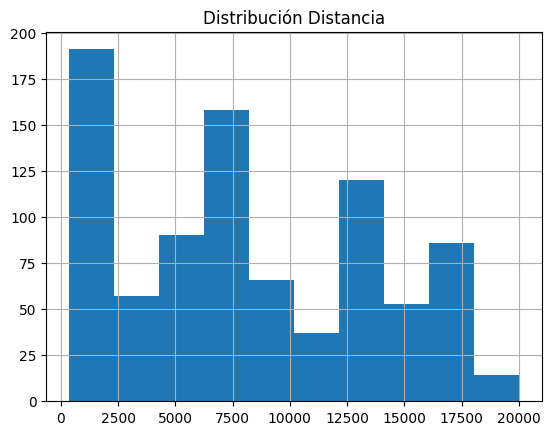

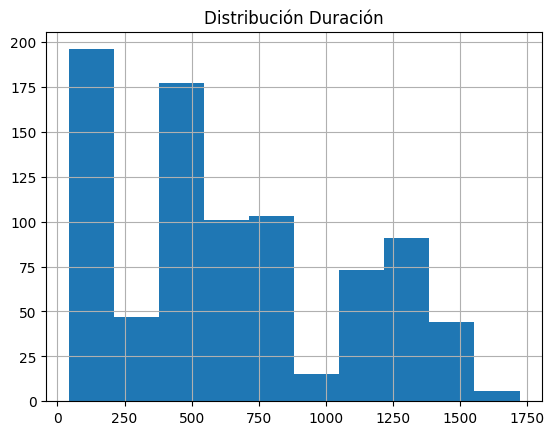

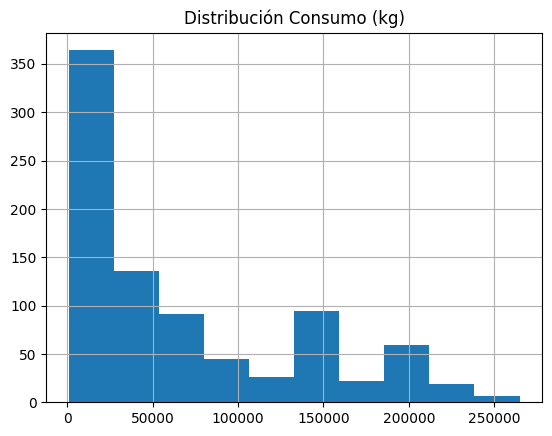

In [16]:
df_viajes_aereos["consumo_kg"] = pd.to_numeric(df_viajes_aereos["consumo_kg"].astype(str).str.replace(",", "."), errors="coerce")

df_viajes_aereos["Distancia"].hist()
plt.title("Distribución Distancia")
plt.show()

df_viajes_aereos["duracion"].hist()
plt.title("Distribución Duración")
plt.show()

df_viajes_aereos["consumo_kg"].hist()
plt.title("Distribución Consumo (kg)")
plt.show()

In [17]:
df_viajes_aereos["consumo_kg"].describe()

count       862.000000
mean      67414.758561
std       67265.241004
min         835.920000
25%       15646.369050
50%       36033.998000
75%      112596.827600
max      264876.314560
Name: consumo_kg, dtype: float64

# Limpieza de Datos

In [18]:
df_viajes_aereos.duplicated().sum()


np.int64(37)

In [19]:
df_viajes_aereos[df_viajes_aereos.duplicated(keep=False)]["Aircompany"].value_counts()

Aircompany
TabarAir      22
MoldaviAir    20
PamPangea     12
Airnar        12
FlyQ           8
Name: count, dtype: int64

In [20]:
(df_viajes_aereos.isna().mean() * 100).sort_values(ascending=False)

duracion      14.7
consumo_kg    13.8
Distancia     12.8
Aircompany     0.0
Origen         0.0
Destino        0.0
avion          0.0
dtype: float64

In [21]:
for col in df_viajes_aereos.columns:
    print("----", col, "----")
    print(df_viajes_aereos[col].value_counts(dropna=False).head(10))
    print()

---- Aircompany ----
Aircompany
TabarAir      229
MoldaviAir    226
PamPangea     192
Airnar        180
FlyQ          173
Name: count, dtype: int64

---- Origen ----
Origen
Bali           134
Ginebra        134
Cincinnati     119
Londres        112
Nueva York     106
París           94
Melbourne       86
Los Angeles     71
Cádiz           55
Roma            55
Name: count, dtype: int64

---- Destino ----
Destino
Cincinnati     125
Bali           122
Londres        111
París          111
Ginebra        102
Nueva York     102
Roma            83
Los Angeles     62
Cádiz           58
Melbourne       52
Name: count, dtype: int64

---- Distancia ----
Distancia
NaN        128
6206.0      41
11980.0     37
12383.0     37
6877.0      34
739.0       31
16900.0     29
6969.0      29
9103.0      28
15011.0     28
Name: count, dtype: int64

---- avion ----
avion
Airbus A380    290
Boeing 747     280
Boeing 737     268
Airbus A320    162
Name: count, dtype: int64

---- consumo_kg ----
consumo_kg
NaN

In [22]:
df_viajes_aereos = df_viajes_aereos.drop_duplicates(keep="last")

In [23]:
df_viajes_aereos = df_viajes_aereos[df_viajes_aereos.isna().sum(axis=1) <= 2]


In [24]:
df_viajes_aereos["consumo_kg"] = pd.to_numeric(df_viajes_aereos["consumo_kg"].astype(str).str.replace(",", "."), errors="coerce")
df_viajes_aereos["consumo_kg"].dtype

dtype('float64')

In [ ]:

consumo_por_avion = df_viajes_aereos.groupby("avion")["consumo_kg"].mean()


consumo_por_avion.sort_values(ascending=False).head(20)

avion
Airbus A380    111184.303168
Boeing 747      97463.508427
Boeing 737      23332.707628
Airbus A320     12508.891285
Name: consumo_kg, dtype: float64

In [ ]:

mean_by_avion = df_viajes_aereos.groupby("avion")["consumo_kg"].transform("mean")


mean_by_company = df_viajes_aereos.groupby("Aircompany")["consumo_kg"].transform("mean")


global_mean = df_viajes_aereos["consumo_kg"].mean()

df_viajes_aereos["consumo_kg"] = df_viajes_aereos["consumo_kg"].fillna(mean_by_avion)
df_viajes_aereos["consumo_kg"] = df_viajes_aereos["consumo_kg"].fillna(mean_by_company)
df_viajes_aereos["consumo_kg"] = df_viajes_aereos["consumo_kg"].fillna(global_mean)

In [ ]:

df_viajes_aereos.select_dtypes(include="object").isna().sum()


df_viajes_aereos = df_viajes_aereos.dropna(subset=df_viajes_aereos.select_dtypes(include="object").columns)

In [ ]:

for col in ["Aircompany", "Origen", "Destino", "avion"]:
    df_viajes_aereos[col] = df_viajes_aereos[col].astype(str).str.strip()
    df_viajes_aereos[col] = df_viajes_aereos[col].replace({"": np.nan})  

ANALISIS DE DATOS

In [29]:
def clasificar_vuelo(dist):
    if pd.isna(dist):
        return np.nan
    if dist > 9000:
        return "LD"
    elif dist >= 1500:
        return "MD"
    else:
        return "R"

df_viajes_aereos["tipo_vuelo"] = df_viajes_aereos["Distancia"].apply(clasificar_vuelo)

In [30]:
df_viajes_aereos["IC"] = df_viajes_aereos["consumo_kg"] / df_viajes_aereos["Distancia"]

In [ ]:

empresa_ic_sum = df_viajes_aereos.groupby("Aircompany")["IC"].sum().sort_values(ascending=False)
empresa_ic_sum.head(3)


df_viajes_aereos.groupby("Aircompany")["IC"].sum().nlargest(3)

Aircompany
TabarAir    2158.263064
FlyQ        1885.599411
Airnar      1655.437591
Name: IC, dtype: float64

In [32]:
df_viajes_aereos.groupby(["tipo_vuelo", "Aircompany"])["IC"].sum().sort_values(ascending=False)

tipo_vuelo  Aircompany
R           TabarAir      978.458057
MD          TabarAir      948.030317
LD          MoldaviAir    930.303134
R           FlyQ          929.841153
LD          PamPangea     650.652086
R           Airnar        602.166909
            PamPangea     576.983662
LD          Airnar        562.523606
MD          Airnar        490.747076
            FlyQ          478.451261
LD          FlyQ          477.306997
MD          MoldaviAir    440.054048
            PamPangea     289.437150
LD          TabarAir      231.774690
R           MoldaviAir    151.934707
Name: IC, dtype: float64

In [33]:
contaminacion_destinos = df_viajes_aereos.groupby("Destino").agg(
    IC_total = ("IC", "sum"),
    num_viajes = ("IC", "count")
)
contaminacion_destinos["IC_medio"] = contaminacion_destinos["IC_total"] / contaminacion_destinos["num_viajes"]
contaminacion_destinos.sort_values("IC_medio", ascending=False).head(10)

,IC_total,num_viajes,IC_medio
Destino,,,
GINEbRA,270.521419,1,270.521419
GINEBrA,150.452372,1,150.452372
BARcelOnA,147.671982,1,147.671982
GIneBra,15.954126,1,15.954126
Barcelona,279.610157,20,13.980508
GInebra,27.380323,2,13.690161
MeLbOUrNE,13.224640,1,13.224640
BarcELONa,12.863968,1,12.863968
MeLbourne,12.623520,1,12.623520


In [37]:
df_viajes_aereos["Destino"] = df_viajes_aereos["Destino"].str.strip().str.title()

In [38]:
contaminacion_destinos = df_viajes_aereos.groupby("Destino").agg(
    IC_total=("IC", "sum"),
    num_viajes=("IC", "count")
)

contaminacion_destinos["IC_medio"] = contaminacion_destinos["IC_total"] / contaminacion_destinos["num_viajes"]

contaminacion_destinos.sort_values("IC_medio", ascending=False).head(2)

,IC_total,num_viajes,IC_medio
Destino,,,
Barcelona,454.647108,24,18.943629
Ginebra,1598.718524,110,14.533805


In [40]:
df_viajes_aereos[df_viajes_aereos["Destino"] == "Barcelona"]["Aircompany"].value_counts().head(1)

Aircompany
FlyQ    26
Name: count, dtype: int64

In [41]:
df_viajes_aereos[df_viajes_aereos["Destino"] == "Ginebra"]["Aircompany"].value_counts().head(1)


Aircompany
PamPangea    38
Name: count, dtype: int64

In [42]:
df_viajes_aereos[
    df_viajes_aereos["Destino"].isin(["Barcelona", "Ginebra"])
]["Aircompany"].value_counts().head(1)

Aircompany
FlyQ    54
Name: count, dtype: int64